# Apply Clustering

In [6]:
!gdown --id 1cO2SQHvkg1SWUJgk4FU_mVx_l_NSnrn8

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1cO2SQHvkg1SWUJgk4FU_mVx_l_NSnrn8
To: /kaggle/working/processed_data_adults.csv
100%|██████████████████████████████████████| 16.2M/16.2M [00:00<00:00, 43.9MB/s]


# Exercise

* Apply K-NN, DBSCAN and GMM over the following dataset
* Visualize using PCA

In [7]:
!gdown --id 1Q6pdhzWFu2oegWMPvrOE8dWTra8FJsTf

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Q6pdhzWFu2oegWMPvrOE8dWTra8FJsTf
To: /kaggle/working/Mall_Customers.csv
100%|██████████████████████████████████████| 3.98k/3.98k [00:00<00:00, 20.4MB/s]


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

Step 3: Preprocess Data

In [10]:
# Drop CustomerID
df = df.drop("CustomerID", axis=1)

# Encode Gender
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [11]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

PCA for Visualization

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

K-Means Clustering

In [13]:
# Reduce features to 2D for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)  # df_scaled from preprocessing step

# Convert to DataFrame for plotting
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

# Add cluster labels for visualization
df_pca['KMeans_Cluster'] = kmeans_labels      # K-Means clusters
df_pca['DBSCAN_Cluster'] = dbscan_labels      # DBSCAN clusters
df_pca['GMM_Cluster'] = gmm_labels            # GMM clusters

NameError: name 'kmeans_labels' is not defined

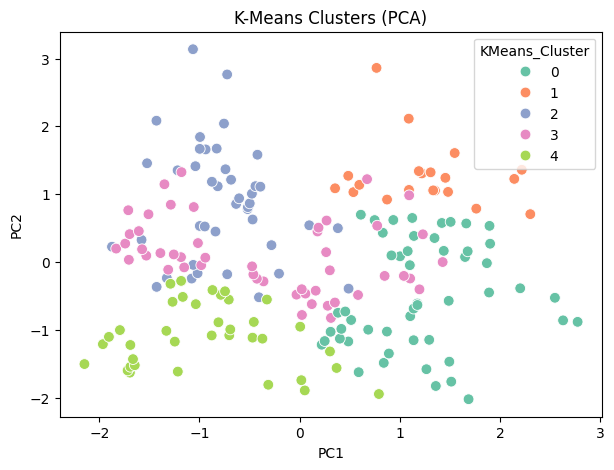

In [15]:
# Fit K-Means (choose 5 clusters as an example)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)
df_pca['KMeans_Cluster'] = kmeans_labels

# Visualize K-Means clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', palette='Set2', data=df_pca, s=60)
plt.title("K-Means Clusters (PCA)")
plt.show()

DBSCAN Clustering

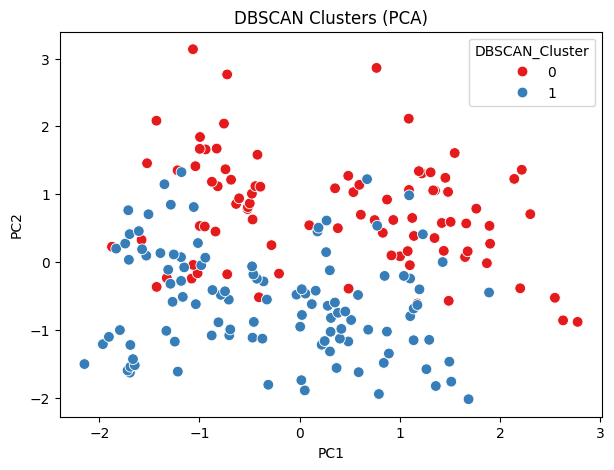

In [16]:
# Fit DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  # tune eps/min_samples if needed
dbscan_labels = dbscan.fit_predict(df_scaled)
df_pca['DBSCAN_Cluster'] = dbscan_labels

# Visualize DBSCAN clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', palette='Set1', data=df_pca, s=60)
plt.title("DBSCAN Clusters (PCA)")
plt.show()

GMM Clustering

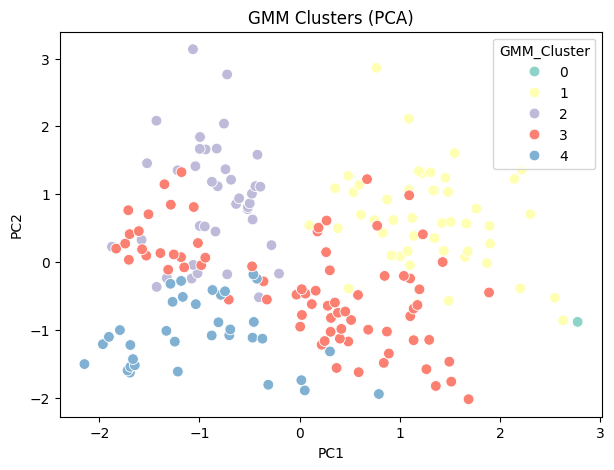

In [17]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(df_scaled)
df_pca['GMM_Cluster'] = gmm_labels

# Visualize GMM clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='PC1', y='PC2', hue='GMM_Cluster', palette='Set3', data=df_pca, s=60)
plt.title("GMM Clusters (PCA)")
plt.show()

Cluster Summary

In [18]:
# Add clusters to original dataset
df['KMeans_Cluster'] = kmeans_labels
df['DBSCAN_Cluster'] = dbscan_labels
df['GMM_Cluster'] = gmm_labels

# Summary statistics
print("K-Means Cluster Summary:")
print(df.groupby('KMeans_Cluster').mean())
print("\nDBSCAN Cluster Summary:")
print(df.groupby('DBSCAN_Cluster').mean())
print("\nGMM Cluster Summary:")
print(df.groupby('GMM_Cluster').mean())

K-Means Cluster Summary:
                  Gender        Age  Annual Income (k$)  \
KMeans_Cluster                                            
0               0.509804  56.470588           46.098039   
1               1.000000  39.500000           85.150000   
2               1.000000  28.690476           60.904762   
3               0.000000  37.897959           82.122449   
4               0.000000  27.315789           38.842105   

                Spending Score (1-100)  DBSCAN_Cluster  GMM_Cluster  
KMeans_Cluster                                                       
0                            39.313725        0.490196     1.960784  
1                            14.050000        0.000000     1.000000  
2                            70.238095        0.000000     1.928571  
3                            54.448980        1.000000     3.040816  
4                            56.210526        1.000000     3.894737  

DBSCAN Cluster Summary:
                Gender        Age  Annual Inco

In [19]:
# K-Means
kmeans_labels = kmeans.fit_predict(df_scaled)

# DBSCAN
dbscan_labels = dbscan.fit_predict(df_scaled)

# GMM
gmm_labels = gmm.fit_predict(df_scaled)

In [20]:
# Apply PCA
pca = PCA(n_components=2)
df_pca_array = pca.fit_transform(df_scaled)

# Convert to DataFrame
df_pca = pd.DataFrame(df_pca_array, columns=['PC1', 'PC2'])

# Add cluster labels
df_pca['KMeans'] = kmeans_labels
df_pca['DBSCAN'] = dbscan_labels
df_pca['GMM'] = gmm_labels

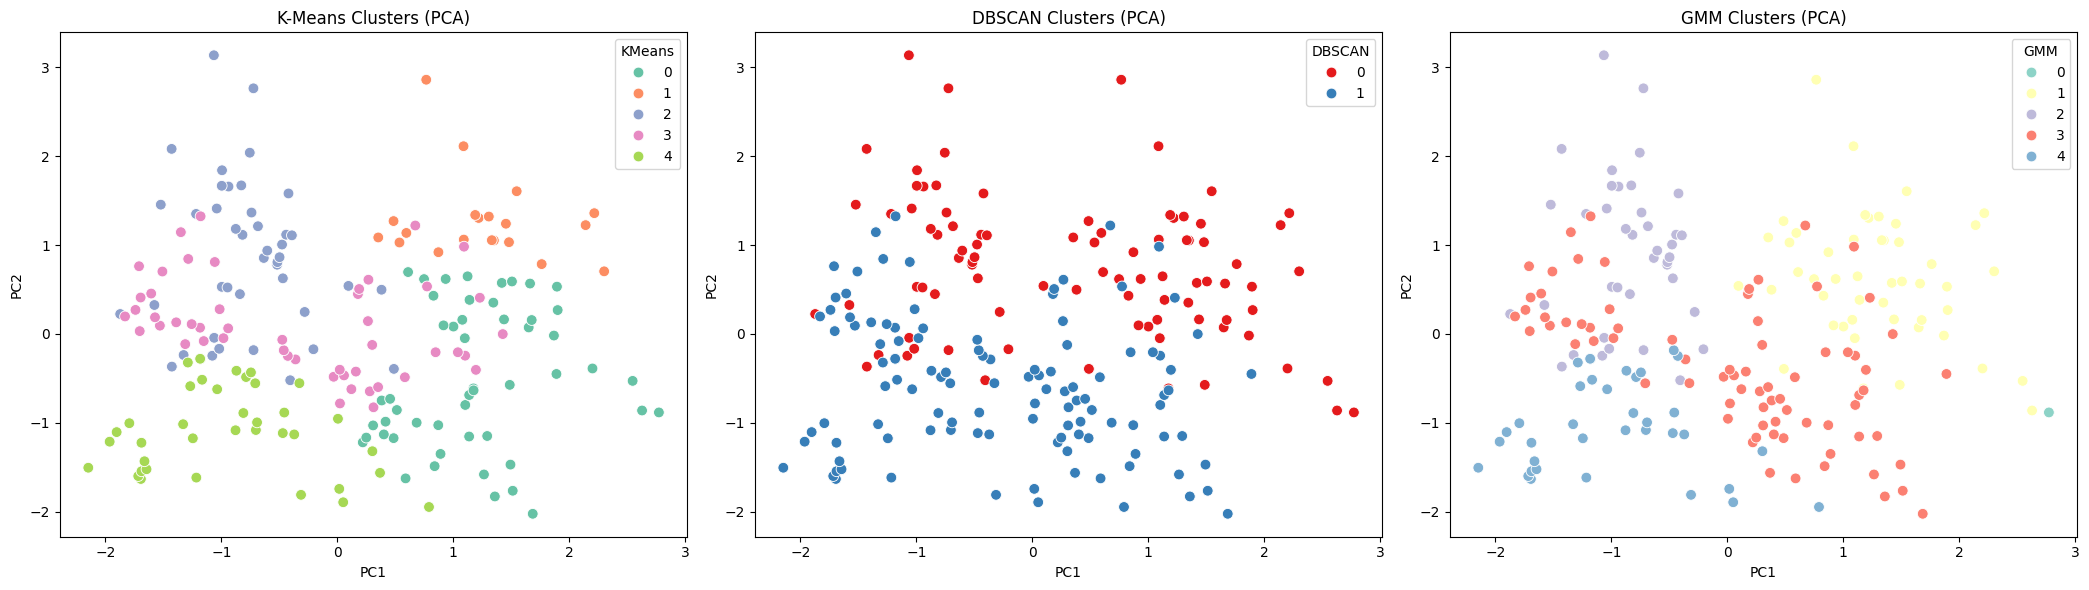

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(21,6))

# K-Means
sns.scatterplot(
    x='PC1', y='PC2', hue='KMeans', palette='Set2', data=df_pca, ax=axes[0], s=60
)
axes[0].set_title("K-Means Clusters (PCA)")

# DBSCAN
sns.scatterplot(
    x='PC1', y='PC2', hue='DBSCAN', palette='Set1', data=df_pca, ax=axes[1], s=60
)
axes[1].set_title("DBSCAN Clusters (PCA)")

# GMM
sns.scatterplot(
    x='PC1', y='PC2', hue='GMM', palette='Set3', data=df_pca, ax=axes[2], s=60
)
axes[2].set_title("GMM Clusters (PCA)")

plt.tight_layout()
plt.show()